# Лабораторная работа: Рекомендательные системы

## Теоретическая часть

### 1. Суть задачи рекомендательных систем
Рекомендательные системы – это алгоритмы, которые анализируют поведение пользователей и предлагают персонализированные рекомендации товаров, фильмов, музыки и других объектов. Основная цель – предсказать предпочтения пользователей на основе имеющихся данных о взаимодействиях.


### 2. Метод коллаборативной фильтрации
Коллаборативная фильтрация (Collaborative Filtering, CF) – это метод рекомендаций, основанный на анализе поведения пользователей. Он работает на основе предположения, что пользователи с похожими предпочтениями в прошлом будут делать схожий выбор в будущем.

Существует два основных подхода:
1. **User-based CF** – рекомендации строятся на основе сходства пользователей.
2. **Item-based CF** – рекомендации строятся на основе сходства объектов.


### 3. Латентные факторные модели (Matrix Factorization)
Коллаборативная фильтрация может быть реализована через матричное разложение. Пусть у нас есть матрица взаимодействий пользователей и объектов R, где $( R_{u,i} )$ – оценка пользователя ( u ) для объекта ( i ). Тогда разложение можно представить в виде:
$$
R \approx U \cdot V^T
$$
где:
- ( U ) – матрица эмбеддингов пользователей,
- ( V ) – матрица эмбеддингов объектов.

Предсказание рейтинга рассчитывается как:
$$
\hat{R}_{u,i} = U_u \cdot V_i^T
$$

В данной лабораторной работе предполагается использование **нейросетевого метода**, который обучает эмбеддинги пользователей и объектов с помощью полносвязных слоев. Входные данные – индексы пользователей и объектов, которые преобразуются в векторные представления, а затем подаются на вход нейросети.


В работе реализуется модель коллаборативной фильтрации на основе нейронной сети (Neural Collaborative Filtering).  
Используются реальные пользовательские оценки книг и обучаем модель предсказывать рейтинг.

Работа включает:
- загрузку и анализ данных
- предобработку
- построение нейросетевой модели
- обучение
- оценку качества (RMSE, MAE)
- визуализацию обучения
- генерацию персональных рекомендаций

Данный подход широко используется в современных рекомендательных системах (Amazon, Netflix, Goodreads).


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import math
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Загрузка данных

In [2]:
books = pd.read_csv("books_of_the_decade.csv")
reviews = pd.read_csv("user_reviews_dataset.csv")

print("Books shape:", books.shape)
print("Reviews shape:", reviews.shape)
books.head(3)

Books shape: (2329, 6)
Reviews shape: (600000, 3)


,Index,Book Name,Author,Rating,Number of Votes,Score
0,1,The Invisible Life of Addie LaRue,Victoria Schwab,4.18,"1,184,531",62443
1,2,The House in the Cerulean Sea (Cerulean Chroni...,T.J. Klune,4.40,"718,243",47323
2,3,Project Hail Mary,Andy Weir,4.51,"657,869",45972


## 2. Предобработка

In [3]:
# Чистим Number of Votes
books["Number of Votes"] = (
    books["Number of Votes"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
)
books["Number of Votes"] = pd.to_numeric(books["Number of Votes"], errors="coerce")

# Кодируем пользователей и книги (начинаем с 0)
user_encoder = {uid: i for i, uid in enumerate(reviews["userId"].unique())}
reviews["user_id"] = reviews["userId"].map(user_encoder)

book_encoder = {bid: i for i, bid in enumerate(reviews["bookIndex"].unique())}
reviews["item_id"] = reviews["bookIndex"].map(book_encoder)

num_users = len(user_encoder)
num_items = len(book_encoder)

print(f"Users: {num_users:,}   Items: {num_items:,}")

Users: 79,957   Items: 2,327


## 3. Dataset и DataLoader

In [4]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df["user_id"].values, dtype=torch.long)
        self.items = torch.tensor(df["item_id"].values, dtype=torch.long)
        self.ratings = torch.tensor(df["score"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]


# 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(reviews, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df):,}   Val: {len(val_df):,}   Test: {len(test_df):,}")

train_loader = DataLoader(RatingsDataset(train_df), batch_size=512, shuffle=True)
val_loader   = DataLoader(RatingsDataset(val_df),   batch_size=512, shuffle=False)
test_loader  = DataLoader(RatingsDataset(test_df),  batch_size=512, shuffle=False)

Train: 420,000   Val: 90,000   Test: 90,000


## 4. Модель (Neural Collaborative Filtering)

In [5]:
class RecommenderNN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=128):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.item_emb = nn.Embedding(num_items, embedding_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, users, items):
        u = self.user_emb(users)
        i = self.item_emb(items)
        x = torch.cat([u, i], dim=1)
        return self.mlp(x).squeeze(-1)


model = RecommenderNN(num_users, num_items, embedding_dim=128).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0008, weight_decay=1e-5)

## 5. Обучение + early stopping

In [6]:
num_epochs = 40
patience = 6
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for users, items, ratings in train_loader:
        users, items, ratings = users.to(device), items.to(device), ratings.to(device)
        optimizer.zero_grad()
        preds = model(users, items)
        loss = criterion(preds, ratings)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for users, items, ratings in val_loader:
            users, items, ratings = users.to(device), items.to(device), ratings.to(device)
            preds = model(users, items)
            val_loss += criterion(preds, ratings).item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:2d} | train {train_loss:.4f} | val {val_loss:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("  → saved best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch  1 | train 2.2649 | val 2.0785
  → saved best model
Epoch  2 | train 2.0627 | val 2.0375
  → saved best model
Epoch  3 | train 2.0194 | val 2.0471
Epoch  4 | train 1.9819 | val 2.0319
  → saved best model
Epoch  5 | train 1.9045 | val 2.0724
Epoch  6 | train 1.7943 | val 2.1428
Epoch  7 | train 1.5907 | val 2.2733
Epoch  8 | train 1.1751 | val 2.5788
Epoch  9 | train 0.8000 | val 2.8288
Epoch 10 | train 0.5945 | val 2.8670
Early stopping at epoch 10


## 6. Графики обучения

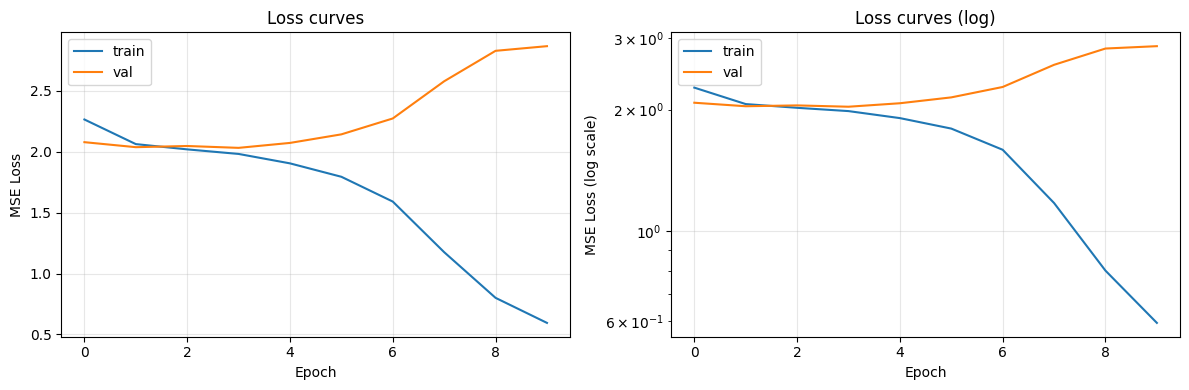

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (log scale)')
plt.title('Loss curves (log)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Оценка на тесте

In [8]:
# загружаем лучшую модель
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

preds_list = []
true_list = []

with torch.no_grad():
    for users, items, ratings in test_loader:
        users, items = users.to(device), items.to(device)
        preds = model(users, items).cpu().numpy()
        preds_list.extend(preds)
        true_list.extend(ratings.numpy())

rmse = math.sqrt(mean_squared_error(true_list, preds_list))
mae  = mean_absolute_error(true_list, preds_list)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")

Test RMSE: 1.4235
Test MAE:  1.2259


## 8. Визуальный анализ предсказаний

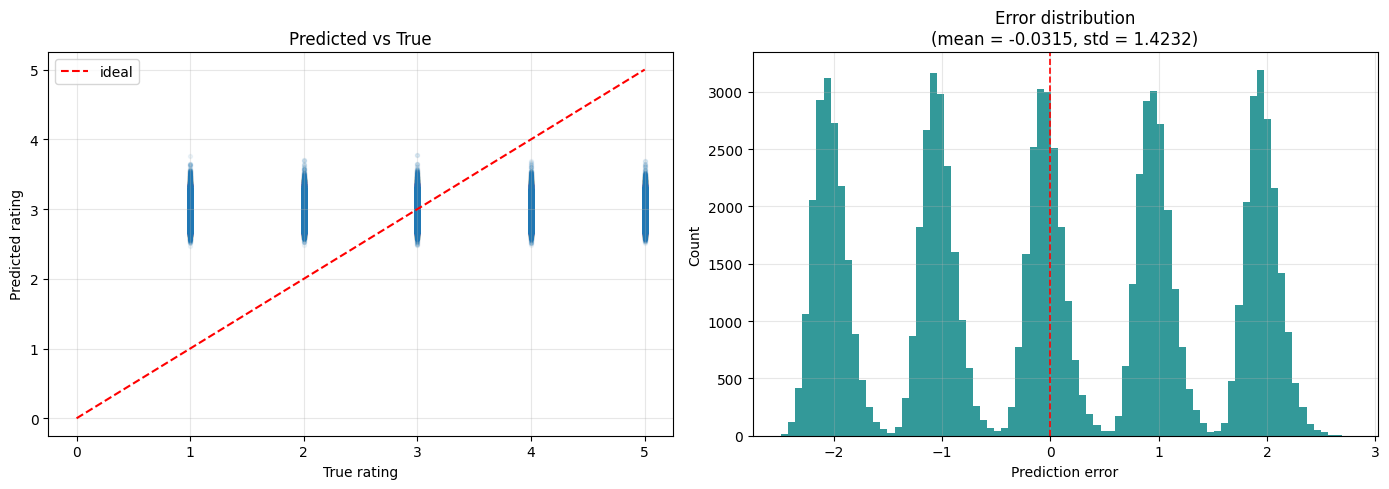

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(true_list, preds_list, alpha=0.07, s=8)
plt.plot([0,5], [0,5], 'r--', lw=1.5, label='ideal')
plt.xlabel('True rating')
plt.ylabel('Predicted rating')
plt.title('Predicted vs True')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
errors = np.array(preds_list) - np.array(true_list)
plt.hist(errors, bins=80, color='teal', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', lw=1.2)
plt.xlabel('Prediction error')
plt.ylabel('Count')
plt.title(f'Error distribution\n(mean = {errors.mean():.4f}, std = {errors.std():.4f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()